In [32]:
import os
import random
from dataclasses import dataclass, asdict
from typing import Tuple, Optional, Any, Dict, List, Counter
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from huggingface_hub import login
import load_dotenv
import os
from pathlib import Path
import time
import math
import json

In [2]:
load_dotenv.load_dotenv(".env")
API_TOKEN = os.getenv("TOKEN")
login(token = API_TOKEN)

In [3]:
# plot style from IKT215, dpi set to 200
def set_mpl_params(dpi: int = 200, figsize: Tuple[int, int] = (9, 6), grid: bool = True, font_size: int = 12, font_family: str = 'serif') -> None:
    mpl.rcParams['figure.dpi'] = dpi
    mpl.rcParams['figure.figsize'] = figsize
    mpl.rcParams['axes.grid'] = grid
    mpl.rcParams.update({'font.size': font_size})
    mpl.rcParams['font.family'] = font_family

In [4]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [5]:
@dataclass
class Config:
    model_name: str = "meta-llama/Llama-3.2-1B"
    dataset_name: str = "yahma/alpaca-cleaned"
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    train_size: int = 10000
    val_size: int = 2000
    test_size: int = 2000
    batch_size: int = 8
    grad_accum_steps: int = 2
    epochs: int = 3
    lr: float = 0.0002
    weight_decay: float = 0.01
    use_bf16: bool = True
    seed: int = 42
    lora_rank: int = 8
    lora_alpha: int = 16
    lora_dropout: float = 0.05
    output_dir: Path = Path("outputs/checkpoints")
    generations_dir: Path = Path("outputs/generations")
    plots_dir: Path = Path("outputs/plots")
    max_length: int = 512
    max_new_tokens: int = 200
    report_to: Optional[str] = "none"
    eval_examples: int = 10
    sampling_examples: int = 10

In [6]:
cfg = Config()
seed_everything(cfg.seed)
set_mpl_params()
cfg.output_dir.mkdir(parents = True, exist_ok = True)
cfg.generations_dir.mkdir(parents  =True, exist_ok = True)
cfg.plots_dir.mkdir(parents = True, exist_ok = True)
cfg

Config(model_name='meta-llama/Llama-3.2-1B', dataset_name='yahma/alpaca-cleaned', device='cuda', train_size=10000, val_size=2000, test_size=2000, batch_size=8, grad_accum_steps=2, epochs=3, lr=0.0002, weight_decay=0.01, use_bf16=True, seed=42, lora_rank=8, lora_alpha=16, lora_dropout=0.05, output_dir=PosixPath('outputs/checkpoints'), generations_dir=PosixPath('outputs/generations'), plots_dir=PosixPath('outputs/plots'), max_length=512, max_new_tokens=200, report_to='none', eval_examples=10, sampling_examples=10)

In [7]:
raw_dataset = load_dataset(cfg.dataset_name)
raw_dataset = raw_dataset["train"].shuffle(seed = cfg.seed)
train_dataset = raw_dataset.select(range(cfg.train_size))
val_dataset = raw_dataset.select(range(cfg.train_size, cfg.train_size + cfg.val_size))
test_dataset = raw_dataset.select(range(cfg.train_size + cfg.val_size, cfg.train_size + cfg.val_size + cfg.test_size))
print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 10000
Validation size: 2000
Test size: 2000


In [8]:
dataset = DatasetDict({"train": train_dataset, "validation": val_dataset, "test": test_dataset})
dataset

DatasetDict({
    train: Dataset({
        features: ['output', 'input', 'instruction'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['output', 'input', 'instruction'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['output', 'input', 'instruction'],
        num_rows: 2000
    })
})

In [9]:
def formatting(example: Dict[str, Any]) -> Dict[str, Any]:
    instruction: str = example["instruction"]
    input: str = example["input"]
    output: str = example["output"]

    if input:
        prompt = f"Instruction: {instruction}\nInput: {input}\nAnswer:"
    else:
        prompt = f"Instruction: {instruction}\nAnswer:"

    text = prompt + " " + output
    return {"prompt": prompt, "response": output, "text": text, "instruction": instruction, "input": input, "output": output,}

In [10]:
dataset = dataset.map(formatting)
dataset

DatasetDict({
    train: Dataset({
        features: ['output', 'input', 'instruction', 'prompt', 'response', 'text'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['output', 'input', 'instruction', 'prompt', 'response', 'text'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['output', 'input', 'instruction', 'prompt', 'response', 'text'],
        num_rows: 2000
    })
})

In [11]:
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, use_fast = True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

def tokenize(batch) -> dict:
    return tokenizer(batch["text"], truncation = True, max_length = cfg.max_length, padding = "max_length")

In [12]:
tokenized = dataset.map(tokenize, batched = True, remove_columns = dataset["train"].column_names)
tokenized.set_format(type = "torch")
tokenized

Map: 100%|██████████| 2000/2000 [00:00<00:00, 4017.68 examples/s]


DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [13]:
model = AutoModelForCausalLM.from_pretrained(cfg.model_name, torch_dtype = torch.bfloat16 if cfg.use_bf16 else torch.float16, device_map = "auto")
model = prepare_model_for_kbit_training(model)
lora_cfg = LoraConfig(r = cfg.lora_rank, lora_alpha = cfg.lora_alpha, lora_dropout = cfg.lora_dropout, target_modules = ["q_proj", "v_proj", "k_proj", "o_proj"], task_type = "CAUSAL_LM")
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

trainable params: 1,703,936 || all params: 1,237,518,336 || trainable%: 0.1377


In [14]:
collator = DataCollatorForLanguageModeling(tokenizer = tokenizer, mlm = False)
args = TrainingArguments(
    output_dir = str(cfg.output_dir),
    per_device_train_batch_size = cfg.batch_size,
    per_device_eval_batch_size = cfg.batch_size,
    gradient_accumulation_steps = cfg.grad_accum_steps,
    num_train_epochs = cfg.epochs,
    learning_rate = cfg.lr,
    weight_decay = cfg.weight_decay,
    bf16 = cfg.use_bf16,
    logging_steps = 25,
    evaluation_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    report_to = cfg.report_to)

/home/coder/emerging/final_project/ikt526/final_project/.venv/lib/python3.12/site-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [15]:
args

TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=True,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
dispatch_batches=None,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_u

In [16]:
trainer = Trainer(model = model, args = args, train_dataset = tokenized["train"], eval_dataset = tokenized["validation"], data_collator = collator)

In [17]:
torch.cuda.reset_peak_memory_stats()
start_time = time.time()
train_result = trainer.train()
end_time = time.time()
train_time_sec: float = end_time - start_time
train_time_min: float = train_time_sec / 60.0
gpu_memory: Optional[float] = None
gpu_memory = torch.cuda.max_memory_allocated() / (1024 ** 3)
print(f"Training time is {train_time_min:.2f} minutes")
print(f"Top GPU memory is {gpu_memory:.2f} GB")
trainer.save_model(cfg.output_dir / "lora_best")
train_stats = {"train_time_sec": train_time_sec, "train_time_min": train_time_min, "gpu_memory_gb": gpu_memory,}
train_stats

Epoch,Training Loss,Validation Loss
1,1.330000,1.339434
2,1.308400,1.330874
3,1.315800,1.331361


Training time is 156.37 minutes
Top GPU memory is 24.98 GB


{'train_time_sec': 9382.010934829712,
 'train_time_min': 156.36684891382853,
 'gpu_memory_gb': 24.98135757446289}

In [18]:
def plot_curves(log_history: List[Dict[str, Any]], cfg: Config) -> None:
    save_path = cfg.plots_dir / "loss_curves.png"
    train_steps = []
    train_losses = []
    eval_steps = []
    eval_losses = []
    for log in log_history:
        if "step" in log and "loss" in log:
            train_steps.append(log["step"])
            train_losses.append(log["loss"])
        if "step" in log and "eval_loss" in log:
            eval_steps.append(log["step"])
            eval_losses.append(log["eval_loss"])

    plt.figure()
    if train_steps:
        plt.plot(train_steps, train_losses, label = "Train loss")
    if eval_steps:
        plt.plot(eval_steps, eval_losses, label = "Validation loss")

    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi = 250)
    plt.show()

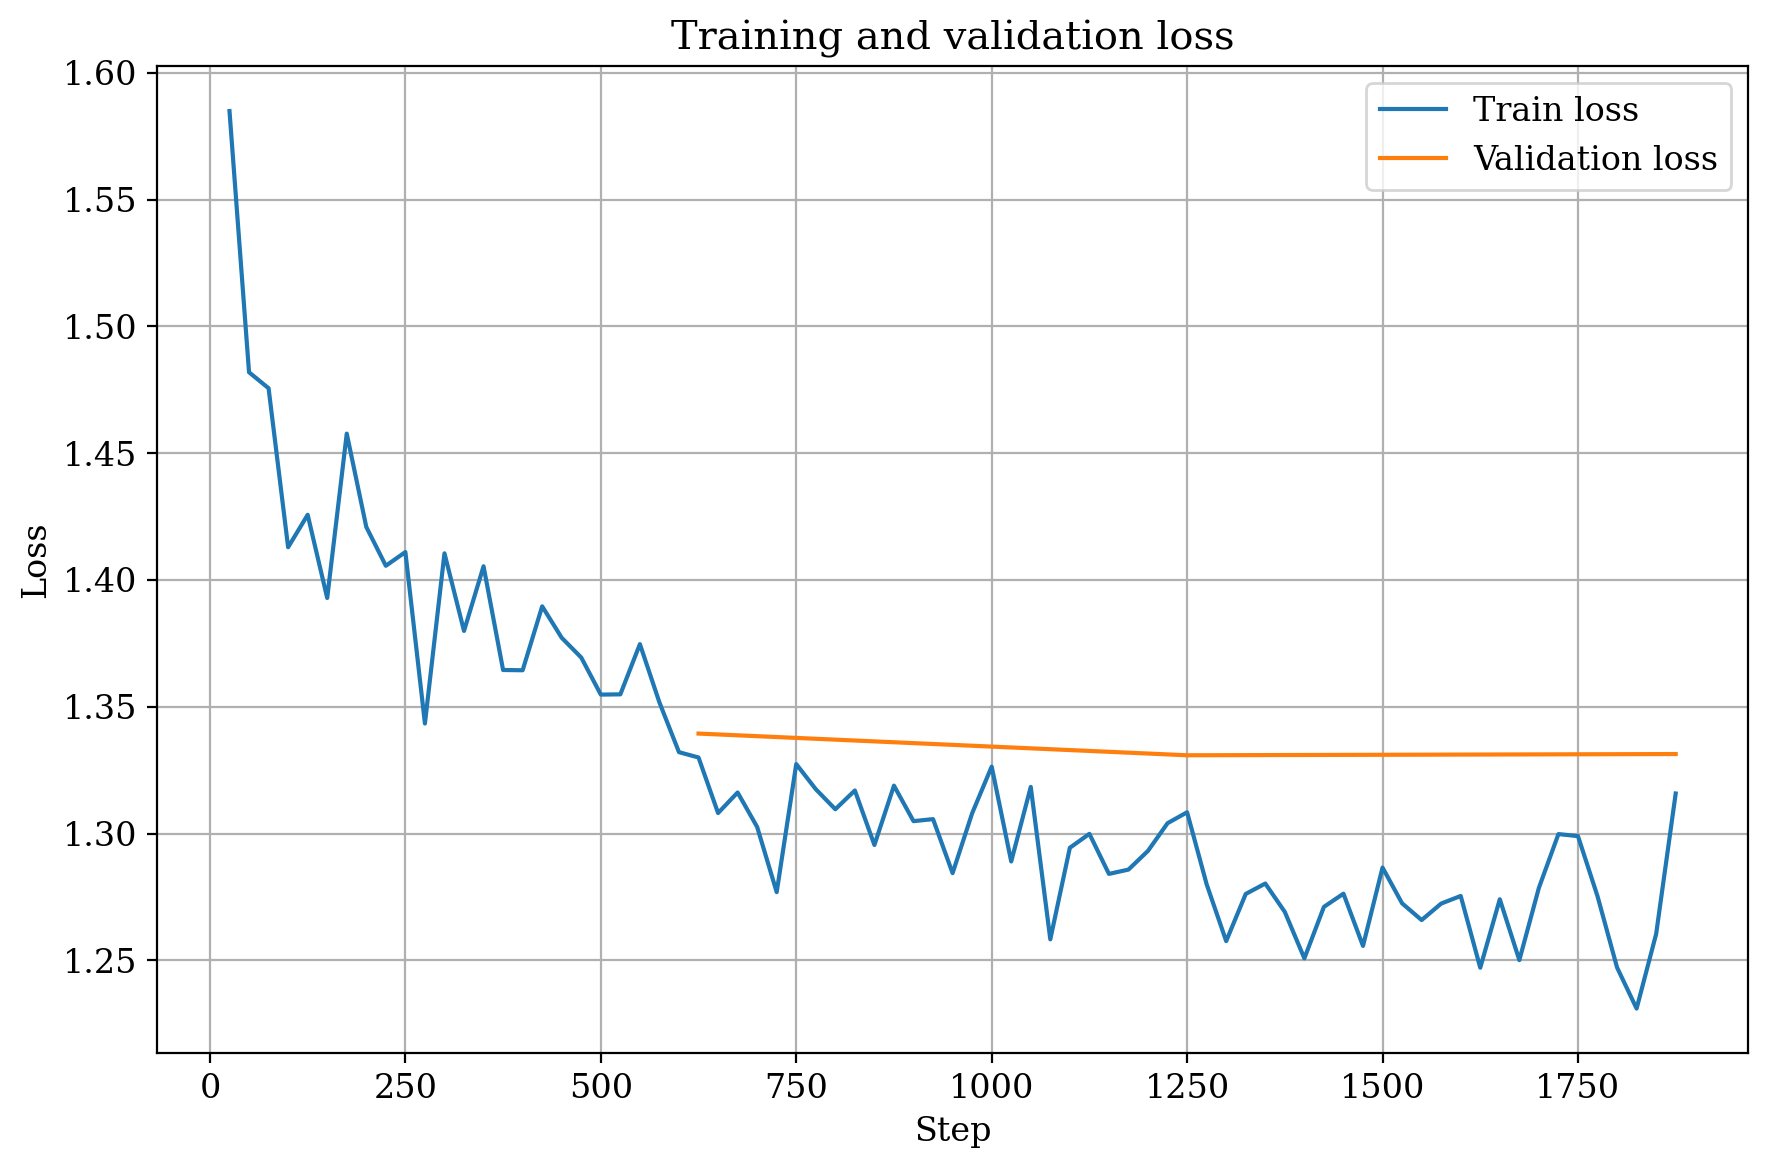

In [19]:
plot_curves(trainer.state.log_history, cfg)

In [20]:
def generate_answer(model: torch.nn.Module, prompt: str, max_new_tokens: int = None, **gen_kwargs: Any) -> str:
    if max_new_tokens is None:
        max_new_tokens = cfg.max_new_tokens
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_ids = inputs["input_ids"]
    input_length = input_ids.shape[1]
    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens = max_new_tokens, pad_token_id = tokenizer.eos_token_id, **gen_kwargs)
    gen_ids = output_ids[:, input_length:]
    text = tokenizer.decode(gen_ids[0], skip_special_tokens = True)
    return text.strip()

In [21]:
def compute_log_likelihood(model: torch.nn.Module, text: str) -> Tuple[float, int]:
    model.eval()
    enc = tokenizer(text, return_tensors = "pt", truncation = True, max_length = cfg.max_length).to(model.device)
    input_ids = enc["input_ids"]
    with torch.no_grad():
        outputs = model(input_ids = input_ids)
        logits = outputs.logits  # [B, T, V]

    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]
    log_probs = torch.log_softmax(shift_logits, dim=-1)
    token_log_probs = log_probs.gather(-1, shift_labels.unsqueeze(-1)).squeeze(-1)
    mask = shift_labels != tokenizer.pad_token_id
    token_log_probs = token_log_probs[mask]
    total_logprob = token_log_probs.sum().item()
    token_count = int(mask.sum().item())
    return total_logprob, token_count

In [22]:
def compute_perplexity(model: torch.nn.Module, text: str) -> float:
    total_logprob, token_count = compute_log_likelihood(model, text)
    if token_count == 0:
        return float("inf")
    # PPL = exp(-1/N sum log p)
    return math.exp(-total_logprob / token_count)

In [23]:
def token_f1(pred: str, ref: str) -> float:
    pred_tokens = pred.split()
    ref_tokens = ref.split()

    if not pred_tokens or not ref_tokens:
        return 0.0

    pred_counter = Counter(pred_tokens)
    ref_counter = Counter(ref_tokens)

    common = sum((pred_counter & ref_counter).values())
    if common == 0:
        return 0.0

    precision = common / len(pred_tokens)
    recall = common / len(ref_tokens)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

In [24]:
base_eval_model = AutoModelForCausalLM.from_pretrained(cfg.model_name, torch_dtype = torch.bfloat16 if cfg.use_bf16 else torch.float16, device_map = "auto")
def select_eval_examples(ds, num_examples: int, seed: int) -> List[Dict[str, Any]]:
    rng = random.Random(seed)
    indices = list(range(len(ds)))
    rng.shuffle(indices)
    selected = indices[:num_examples]
    return [ds[i] for i in selected]

In [26]:
eval_examples = select_eval_examples(dataset["test"], cfg.eval_examples, cfg.seed)
len(eval_examples)

10

In [ ]:
results = []
base_ppls = []
base_f1s = []
ft_ppls = []
ft_f1s = []

for i, ex in enumerate(eval_examples):
    example_id = i
    instruction = ex["instruction"]
    inp = ex["input"]
    reference = ex["output"]

    if inp:
        prompt = f"Instruction: {instruction}\nInput: {inp}\nAnswer:"
    else:
        prompt = f"Instruction: {instruction}\nAnswer:"

    # base model generation
    base_answer = generate_answer(base_eval_model, prompt, do_sample = False)
    # lora model generation
    ft_answer = generate_answer(model, prompt, do_sample = False)

    # metrics, perplexity on generated output only
    base_ppl = compute_perplexity(base_eval_model, base_answer)
    ft_ppl = compute_perplexity(model, ft_answer)
    base_f1_val = token_f1(base_answer, reference)
    ft_f1_val = token_f1(ft_answer, reference)
    base_ppls.append(base_ppl)
    base_f1s.append(base_f1_val)
    ft_ppls.append(ft_ppl)
    ft_f1s.append(ft_f1_val)

    results.append(
        {
            "example_id": example_id,
            "instruction": instruction,
            "input": inp,
            "reference_output": reference,
            "base_output": base_answer,
            "finetuned_output": ft_answer,
            "base_metrics": {
                "perplexity": base_ppl,
                "f1": base_f1_val,
                "qualitative_score": None
            },
            "finetuned_metrics": {
                "perplexity": ft_ppl,
                "f1": ft_f1_val,
                "qualitative_score": None
            },
        })

/home/coder/emerging/final_project/ikt526/final_project/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/coder/emerging/final_project/ikt526/final_project/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


In [34]:
def serialize_config(cfg_dict):
    out = {}
    for k, v in cfg_dict.items():
        if isinstance(v, Path):
            out[k] = str(v)
        else:
            out[k] = v
    return out

In [36]:
summary = {
    "base": {
        "ppl_mean": float(np.mean(base_ppls)),
        "ppl_std": float(np.std(base_ppls)),
        "f1_mean": float(np.mean(base_f1s)),
        "f1_std": float(np.std(base_f1s)),
    },
    "finetuned": {
        "ppl_mean": float(np.mean(ft_ppls)),
        "ppl_std": float(np.std(ft_ppls)),
        "f1_mean": float(np.mean(ft_f1s)),
        "f1_std": float(np.std(ft_f1s)),
    },
}

eval_report = {
    "config": serialize_config(asdict(cfg)),
    "train_stats": train_stats,
    "summary": summary,
    "examples": results,
}

in_dist_path = cfg.generations_dir / "in_distribution_eval.json"
with open(in_dist_path, "w") as f:
    json.dump(eval_report, f, indent=4)

In [37]:
summary

{'base': {'ppl_mean': 2.013452531864395,
  'ppl_std': 1.3229657914247004,
  'f1_mean': 0.1892498608444111,
  'f1_std': 0.1666285496881676},
 'finetuned': {'ppl_mean': 2.269051580478617,
  'ppl_std': 0.5025415721801302,
  'f1_mean': 0.24976875942956314,
  'f1_std': 0.15633103120637742}}

In [38]:
def greedy_sampling(prompt: str) -> str:
    return generate_answer(model, prompt, do_sample = False)

def temperature_sampling(prompt: str, temperature: float = 0.7) -> str:
    return generate_answer(model, prompt, do_sample = True, temperature = temperature, top_p = None)

def nucleus_sampling(prompt: str, top_p: float = 0.9) -> str:
    return generate_answer(model, prompt, do_sample = True, top_p = top_p, temperature = 1.0)

In [39]:
ood_prompts: List[str] = [
    "Explain the difference between supervised, unsupervised, and reinforcement learning.",
    "Write a short story about a robot that refuses to follow its programming.",
    "Explain the concept of attention in transformers to a high school student.",
    "Generate a Python function that implements binary search.",
    "Describe three potential ethical risks of using generative AI in education.",
    "Summarize the main idea of the Three Laws of Robotics.",
    "Given a list of integers, explain how to find the maximum subarray sum.",
    "Draft an email to a professor requesting an extension on an assignment.",
    "Explain why diffusion models are used for image generation.",
    "Provide step-by-step reasoning to solve: A train travels 120 km in 2 hours. What is its average speed?",
]

len(ood_prompts)

10

In [40]:
sampling_results = []
for i, prompt in enumerate(ood_prompts):
    greedy_out = greedy_sampling(prompt)
    temp_out = temperature_sampling(prompt, temperature = 0.7)
    nucleus_out = nucleus_sampling(prompt, top_p = 0.9)
    sampling_results.append({"example_id": i, "prompt": prompt, "greedy_output": greedy_out, "temperature_0.7_output": temp_out, "top_p_0.9_output": nucleus_out})

/home/coder/emerging/final_project/ikt526/final_project/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/coder/emerging/final_project/ikt526/final_project/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:595: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


In [42]:
sampling_report = {"config": asdict(cfg), "model": "Llama-3.2-1B-LoRA", "examples": sampling_results}
ood_path = cfg.generations_dir / "out_of_distribution_sampling.json"
with open(ood_path, "w") as f:
    json.dump(sampling_report, f, indent = 4, default = str)


In [43]:
len(sampling_results)

10

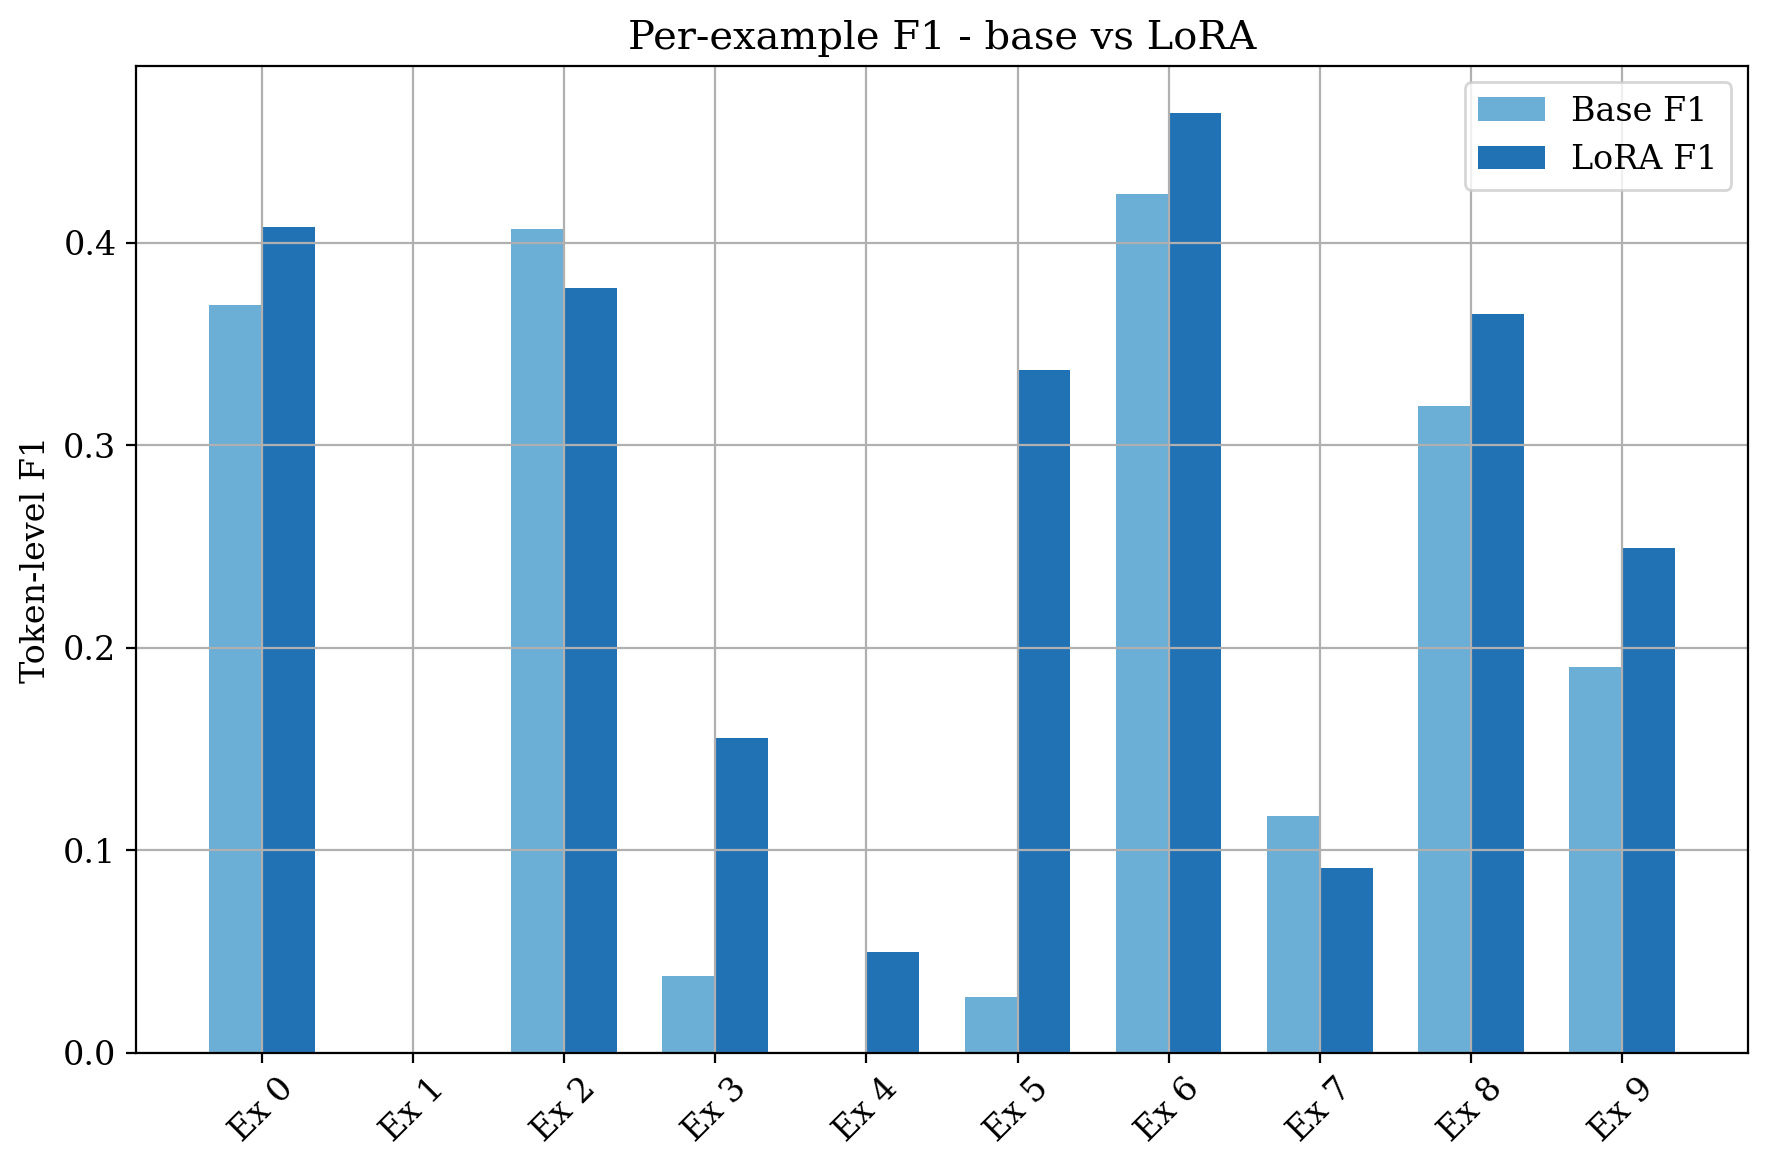

In [ ]:
labels = [f"Ex {i}" for i in range(cfg.eval_examples)]
x = np.arange(len(labels))
width = 0.35
base_color = "#6baed6"
lora_color = "#2171b5"

plt.figure()
plt.bar(x - width/2, base_f1s, width, label = "Base F1", color = base_color)
plt.bar(x + width/2, ft_f1s, width, label = "LoRA F1", color = lora_color)
plt.xticks(x, labels, rotation=45)
plt.ylabel("Token-level F1")
plt.title("Per-example F1 - base vs LoRA")
plt.legend()
plt.tight_layout()
plt.savefig(cfg.plots_dir / "per_example_f1.png")
plt.show()

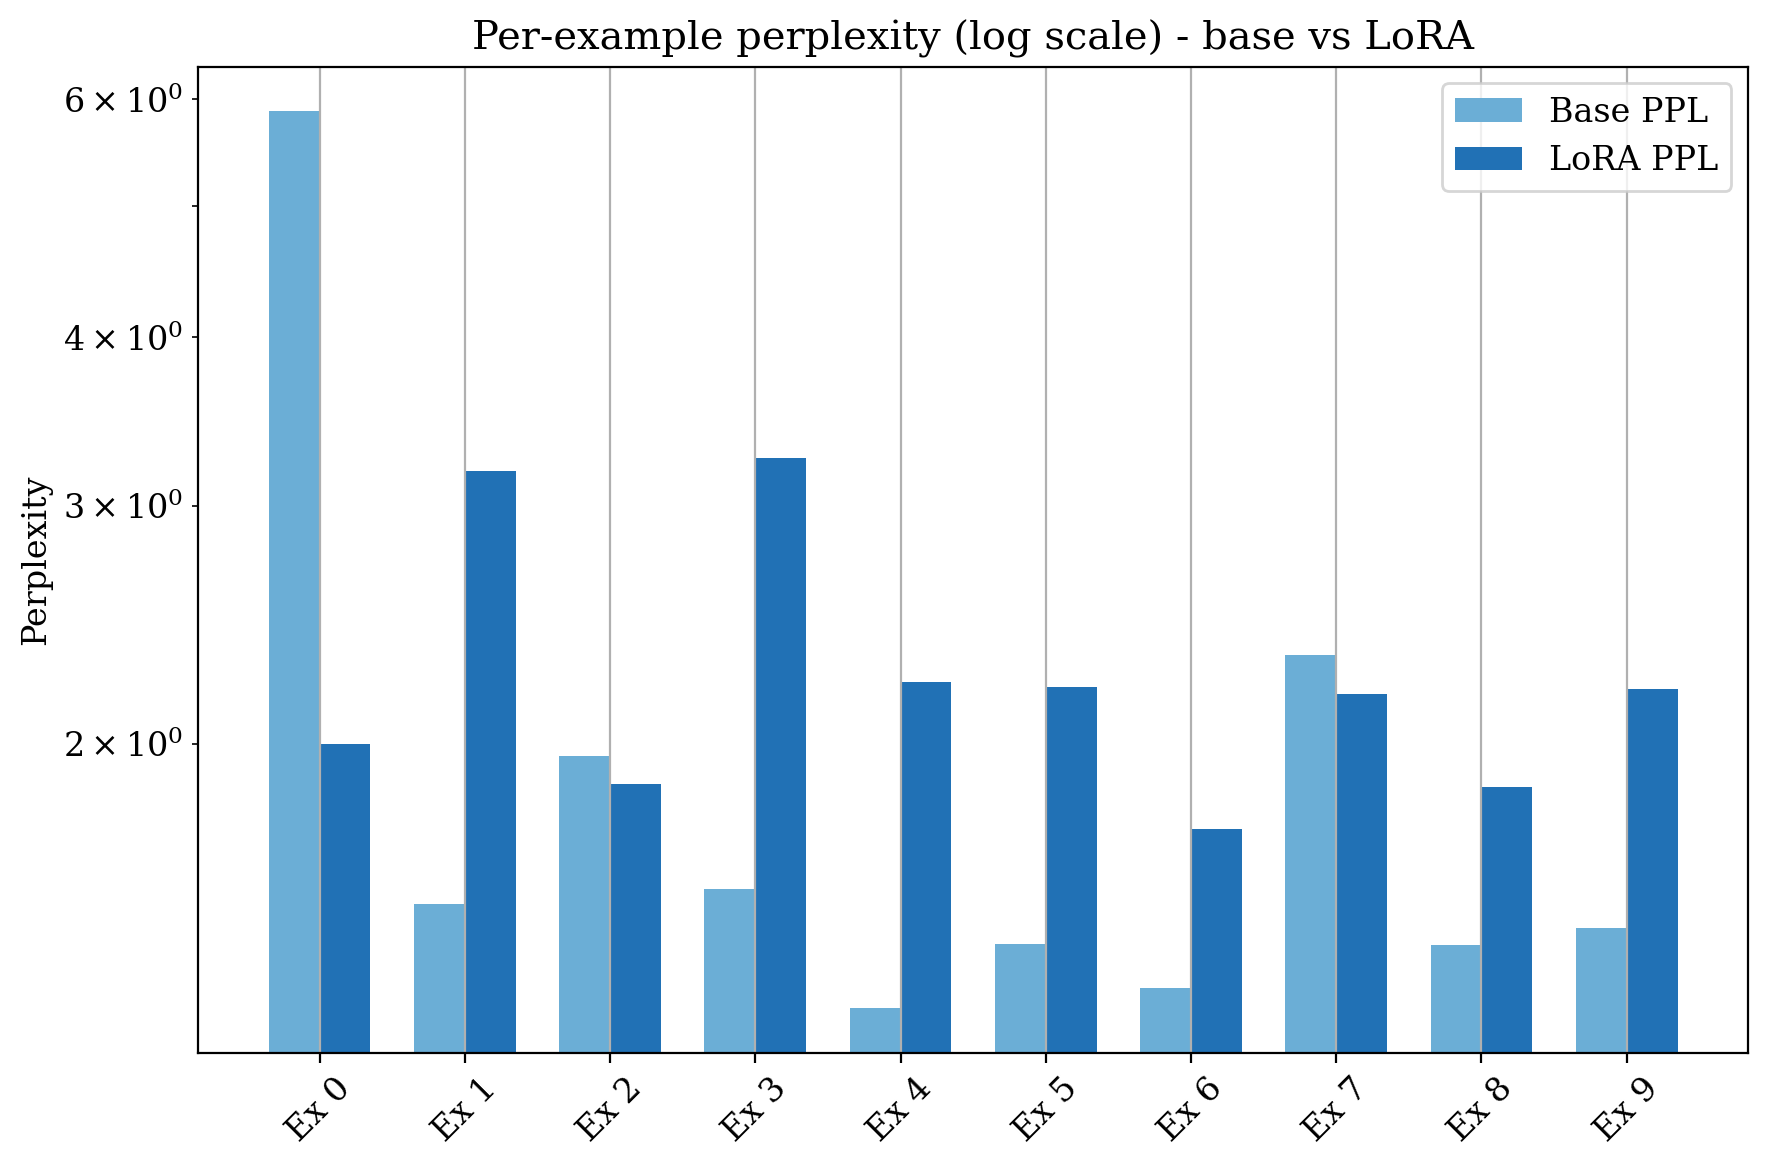

In [48]:
plt.figure()
plt.bar(x - width/2, base_ppls, width, label = "Base PPL", color = base_color)
plt.bar(x + width/2, ft_ppls, width, label = "LoRA PPL", color = lora_color)
plt.xticks(x, labels, rotation=45)
plt.ylabel("Perplexity")
plt.yscale("log")
plt.title("Per-example perplexity (log scale) - base vs LoRA")
plt.legend()
plt.tight_layout()
plt.savefig(cfg.plots_dir / "per_example_perplexity.png")
plt.show()